# 2.1 · PD fine-tuning

*2. Experiment 2 · notebook 2.1 of the story.* ← [1.4 · LGD results](<../1. Experiment 1/1.4_lgd_results.ipynb>) · [2.2 · LGD fine-tuning](<2.2_lgd_finetuning.ipynb>) →

**Experiment 2 asks: once a prior is chosen, how should the released model be adapted to it?**
It continues pre-training from the released TabICLv2 weights
(`checkpoints/tabicl-classifier-v2-20260212.ckpt`) for 10,000
steps and crosses four levers: the **credit fraction** (0, 0.25, 0.5, 0.75, 1), the **freeze
strategy** (`full` — every layer; `icl_only` — the ICL stack and head; `head_only` — the head alone),
**L2-SP** (0, or 0.003 — Real-TabPFN's pull back towards the loaded weights) and the **learning rate**
(1e-6 or 1e-5): 60 arms, one seed each. The filter mode and intensity are to be copied from
Experiment 1's winner — `config/Exp2_PD.yaml` still holds `FILL_FROM_EXP1` in their place.

**Status: no Experiment 2 arm has run.** The sweep map (A1) shows the 60 scheduled arms; every other
figure is a one-line placeholder until arms have run, and fills in as they do. The structure — and the
three averaging rules — are Experiment 1's ([1.1 · PD training](<../1. Experiment 1/1.1_pd_training.ipynb>)).

**The order.** **A** — is the run sound: which arms exist and finished, what each was scored on,
what each cost, whether each learned. **B** — what the development monitoring says about each lever.
**C** — whether it holds on every dataset, outside credit and on every metric. **D** — every arm on
its own.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, pathlib
ROOT = pathlib.Path.cwd()
# Walk up to the repository root — the notebook may be opened from its chapter folder, from
# notebooks/, or from the root — then work FROM the root, so relative paths (config/...) resolve
# exactly as under `python -m src.utils.run_notebooks`.
while not (ROOT / "src" / "visualize").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.visualize import training_plots, figures, style, literature

style.apply()
pd.set_option("display.width", 200, "display.max_columns", 40)

TASK = "pd"
EXP = "exp2"
# Reads output/manifests/ and output/results/ — whatever the runs have written so far, so a
# partial sweep still renders. Constructing the saver clears THIS notebook's figure folder only.
FIGS = figures.FigureSaver("2.1_pd_finetuning")

## A · Is the run sound?

Before any number is read: which arms exist and finished, what each was scored on, what each cost,
and whether each one learned.

### A1 · Which arms exist, and how did each finish?

**What it shows.** Every scheduled arm in one grid: one row per configuration, grouped by credit fraction, one column per seed (for a one-seed sweep, one column per credit fraction instead). A number is the arm's final development ROC-AUC — the mean over the development datasets every arm scored; a grey cell has no development score; a hatched cell is still training and says how far it has got.

**Why it matters.** A reader has to know which arms exist, which finished, and whether a block of rows or one seed stands out, before any comparison means anything: an effect shared by one seed moves every comparison that is not averaged over seeds.

**What it says.** No arm has started: the map is the design — the 60 arms that will run, one per cell.

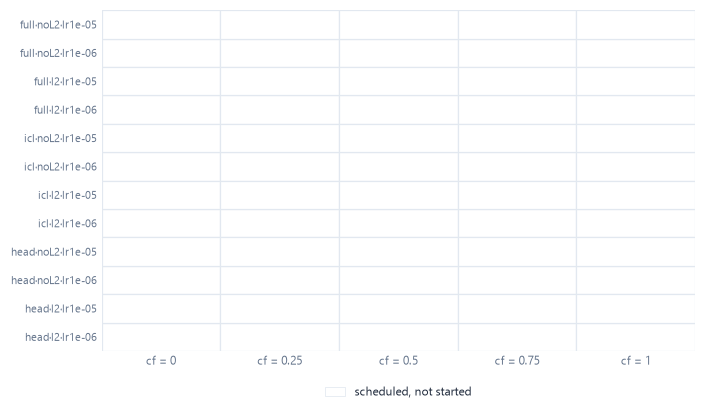

In [2]:
FIGS.save(training_plots.sweep_map(TASK, exp=EXP), "sweep_map",
    caption="Final development ROC-AUC of every scheduled PD arm as a heatmap, one row per configuration grouped by credit fraction and one column per seed; grey cells have no development score, hatched cells are still training with the share of steps done.");

### A2 · What was each arm scored on?

**What it shows.** One row per real dataset (development first, then holdout), one column per arm in the sweep map's order. A cell's colour says what that arm's score on that dataset may do: enter a development mean, exist without being averaged (not every arm carries it), be a holdout score (never averaged), or be a monitor that logged only missing values.

**Why it matters.** Arms were monitored under two protocols. Before 23-09-2026 the monitor scored "the four smallest" real datasets whatever their role, holdout ones included; since then, development datasets only. Averaging a holdout score into "which prior is best" would select on the test set, so this map fixes exactly which cells every curve in Part B is built from.

**What it says.** No arm has run yet; the figure below is a placeholder.

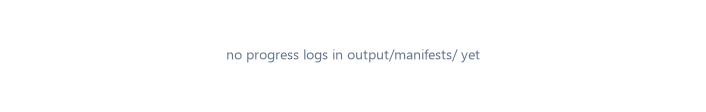

In [3]:
FIGS.save(training_plots.monitoring_coverage(TASK, exp=EXP), "monitoring_coverage",
    caption="Monitoring coverage of every PD arm: one row per real dataset labelled development or holdout, one column per arm grouped by credit fraction, each cell coloured by whether its score enters the development mean, is not carried by every arm, is holdout, holds only missing values or was not monitored.");

### A3 · What did each arm cost?

**What it shows.** Each arm's training speed — its median steps per second over the run — grouped by freeze strategy, and the hours the full run takes at that speed; the bar is the group median, points are coloured and shaped by credit fraction.

**Why it matters.** TabICL generates its training tasks on the CPU while the GPU trains. A filter that throws most generated tasks away makes every batch cost several generations — a cost in walltime and VSC credits that never shows in the loss.

**What it says.** No arm has run yet; the figure below is a placeholder.

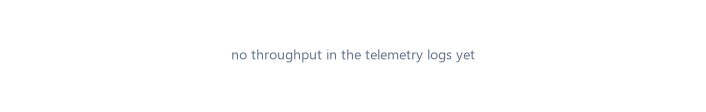

In [4]:
FIGS.save(training_plots.throughput(TASK, exp=EXP), "throughput",
    caption="Training speed per PD arm in steps per second (left) and the implied hours for the full run (right), grouped by freeze strategy; points are arms coloured and shaped by credit fraction and bars are group medians with their value.");

### A4 · Did every arm learn?

**What it shows.** The training loss of every arm against the step — cross-entropy on the arm's own synthetic batch, as a rolling mean over three logged points (each logged value is one batch's loss) — with the median of the finished arms of each credit fraction drawn bold.

**Why it matters.** The loss is the one quantity every arm optimises directly, so divergence or a stall shows here first; TabICLv2's ablations warn that a prior can make training diverge (`papers/2026/02_Qu_TabICLv2` §4.4). But it is computed on each arm's own prior, so its level says which prior an arm trains on — not how well it learned.

**What it says.** No arm has run yet; the figure below is a placeholder.

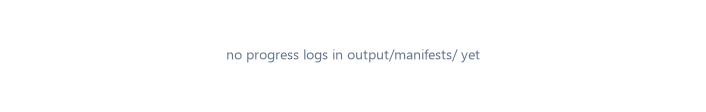

In [5]:
FIGS.save(training_plots.training_loss(TASK, exp=EXP), "training_loss",
    caption="Training loss against optimisation step for every PD arm, a rolling mean over three logged batches coloured by credit fraction and dotted while unfinished, with the median of the finished arms of each credit fraction bold.");

### A5 · Is every part of the network learning?

**What it shows.** Left, each block's gradient norm; right, the gradient divided by the block's weight norm — how far one step moves the block relative to its size. Both are averaged over all arms, on logarithmic axes. The telemetry records the column encoder, the row encoder and the ICL blocks; the prediction head is not logged.

**Why it matters.** A block whose gradient sits orders of magnitude below the others is effectively frozen, and the loss cannot say which one. Under a freeze strategy the frozen blocks should sit on the floor — this is where a reader checks that the freeze took.

**What it says.** No arm has run yet; the figure below is a placeholder.

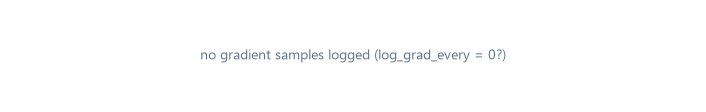

In [6]:
FIGS.save(training_plots.gradient_health(TASK, exp=EXP), "gradient_health",
    caption="Mean per-block gradient L2 norm (left) and ratio of gradient norm to weight norm (right) against training step on logarithmic axes, one line per architecture block (column encoder, row encoder, ICL blocks), averaged over all arms.");

## B · What does the development monitoring say?

The development ROC-AUC over training and at its end, lever by lever. It guides the eye; the benchmark in
[2.3 · PD results](<2.3_pd_results.ipynb>) decides.

### B1 · Development ROC-AUC over training

**What it shows.** The development ROC-AUC of every arm against the step, averaged over the development datasets every arm scored, in its credit-fraction colour and dotted while unfinished, with the mean of the finished arms of each fraction drawn bold.

**Why it matters.** The first look at how models trained on each prior do on real credit data they never trained on — and whether the fractions separate early, late or not at all.

**What it says.** No arm has run yet; the figure below is a placeholder.

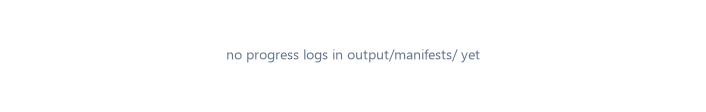

In [7]:
FIGS.save(training_plots.metric_over_training(TASK, exp=EXP), "metric_over_training",
    caption="Development ROC-AUC averaged over the development datasets every arm scored, against training step; one line per arm coloured by credit fraction and dotted while unfinished, with the mean of the finished arms of each credit fraction bold.");

### B2 · Credit prior versus the control

**What it shows.** Credit-prior arms (any credit fraction above 0) against the control arms (credit fraction 0 — TabICL's own prior): the median over the finished arms of each group, with the inter-quartile band.

**Why it matters.** The experiment's comparison, as a curve. A gap narrower than the bands is not read as an effect.

**What it says.** No arm has run yet; the figure below is a placeholder.

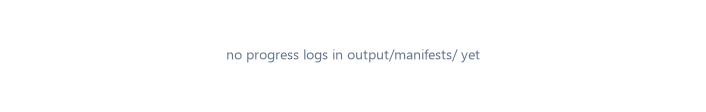

In [8]:
FIGS.save(training_plots.credit_vs_control_over_training(TASK, exp=EXP), "credit_vs_control_over_training",
    caption="Development ROC-AUC against training step for credit-prior arms and control arms: median lines with shaded inter-quartile bands over the finished arms of each group.");

### B3 · Which lever moves the score?

**What it shows.** One panel per swept lever (credit fraction, freeze strategy, L2-SP and learning rate), one mean curve per value over the finished arms that share it, all panels on one y axis.

**Why it matters.** The size of each lever's effect, side by side: a lever whose curves lie on top of each other does nothing, whatever the others do.

**What it says.** No arm has run yet; the figure below is a placeholder.

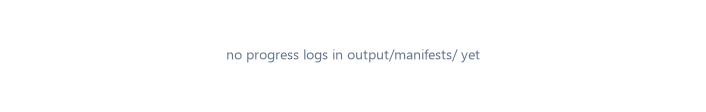

In [9]:
FIGS.save(training_plots.metric_by_levers(TASK, exp=EXP), "metric_by_levers",
    caption="Development ROC-AUC against training step, one panel per swept lever with one mean line per lever value over the finished arms sharing it, all panels on a shared vertical axis.");

### B4 · Final score, lever by lever

**What it shows.** Every finished arm's final development score, grouped by each lever in turn: points coloured and shaped by credit fraction, a bar at each group mean, one shared y axis.

**Why it matters.** Final scores as a screen, one lever at a time. The sweep is factorial, so a lever's groups can differ merely because they contain different credit fractions; B5 separates the two.

**What it says.** No arm has run yet; the figure below is a placeholder.

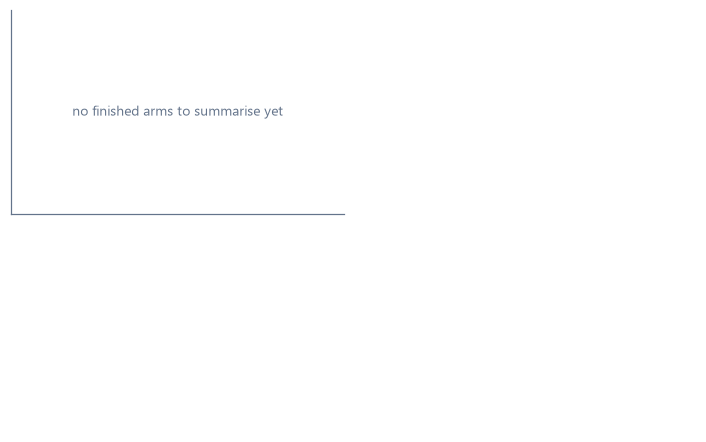

In [10]:
FIGS.save(training_plots.final_metric_by_lever(TASK, exp=EXP), "final_metric_by_lever",
    caption="Final development ROC-AUC of every finished arm as points coloured and shaped by credit fraction, one panel per swept lever, with a horizontal bar at each group mean.");

### B5 · Each lever within each credit fraction

**What it shows.** Each lever other than the credit fraction, drawn within each fraction: points are finished arms, lines join the per-value means, whiskers are ±1 standard deviation over seeds. A lever the control does not have appears as the control's band (its mean ± 1 SD) instead.

**Why it matters.** Pooling a lever over fractions mixes the fraction's larger effect into it; within one fraction, a real effect of the other levers has nowhere to hide.

**What it says.** No arm has run yet; the figure below is a placeholder.

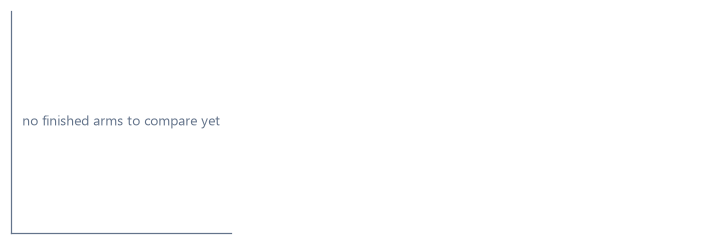

In [11]:
FIGS.save(training_plots.lever_interaction(TASK, exp=EXP), "lever_interaction",
    caption="Final development ROC-AUC against each lever other than credit fraction, one series per credit fraction: points are finished arms, lines join the per-value means, whiskers show one standard deviation over seeds, and the grey band is the control mean plus or minus one standard deviation.");

### B6 · Effect against seed noise

**What it shows.** Every configuration's seeds on one axis, best configuration at the top: points are seeds, the line their range, the tick their mean; the dashed line is the control's mean.

**Why it matters.** A difference between two configurations is only worth reading where it clearly exceeds the spread between one configuration's own seeds — Experiment 2 runs one seed, so this figure will show single runs.

**What it says.** No arm has run yet; the figure below is a placeholder.

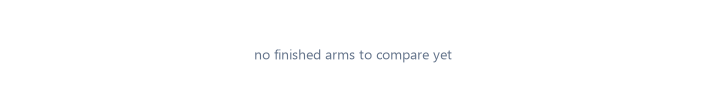

In [12]:
FIGS.save(training_plots.seed_spread(TASK, exp=EXP), "seed_spread",
    caption="Final development ROC-AUC of every configuration's seeds as points on one horizontal axis, configurations sorted by their mean with the range and mean marked per row; the dashed line is the control mean.");

## C · Where does it hold?

A mean can be carried by one easy dataset, and a gain on credit can be bought with general ability.
These figures check both, and every metric the monitor records.

### C1 · Every monitored dataset

**What it shows.** One panel per real dataset the monitor scored, development first: the mean over the finished credit-prior arms and over the finished control arms that scored it. Each title gives the dataset's side of the split and how many finished arms scored it.

**Why it matters.** Development panels are what the means above are built from. Holdout panels are shown as the evidence they are and never enter a mean — they belong to the benchmark.

**What it says.** No arm has run yet; the figure below is a placeholder.

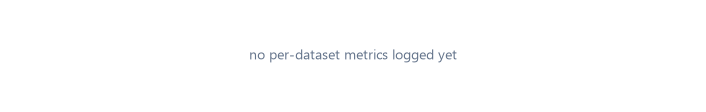

In [13]:
for _p in range(1, training_plots.per_dataset_pages(TASK, exp=EXP) + 1):
    FIGS.save(training_plots.per_dataset_curves(TASK, _p, exp=EXP), f"per_dataset_p{_p}",
        caption="Monitored ROC-AUC against training step, one panel per real dataset labelled with its side of the split and the number of finished arms that scored it, credit-prior arms against control arms.");

### C2 · Credit data against out-of-domain data

**What it shows.** The development score on the real credit datasets (solid) and on eight public classification suites from outside credit (dashed), each averaged separately over credit-prior and control arms.

**Why it matters.** Out-of-domain retention is a first-class axis of the design (`docs/EXPERIMENTAL_DESIGN.md` §5.3): a prior that lifts credit scores by making the model worse everywhere else has not made it better.

**What it says.** No arm has run yet; the figure below is a placeholder.

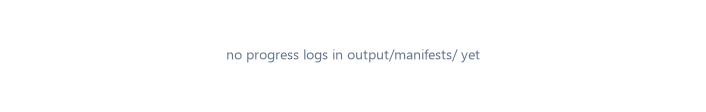

In [14]:
FIGS.save(training_plots.real_vs_ood(TASK, exp=EXP), "real_vs_ood",
    caption="Development ROC-AUC on the real-credit datasets (solid) and on the out-of-domain suites (dashed) against training step, averaged separately over credit-prior and control arms.");

### C3 · Every development metric

**What it shows.** Every metric the monitor records, one figure per group (for LGD: accuracy; ranking and calibration; intervals and boundary atoms), one panel per metric: the mean over finished credit-prior and control arms. A title carries the metric's goal — ↑ higher is better, ↓ lower is better, → a value it should equal, drawn dashed; a predicted boundary share is drawn against the true share in the data.

**Why it matters.** The PD monitor logs only ROC-AUC and PR-AUC; PR-AUC depends on the base rate, so it is compared between arms on the same datasets, never across them. The calibration metrics (Brier, log-loss, calibration slope) arrive with the benchmark.

**What it says.** No arm has run yet; the figure below is a placeholder.

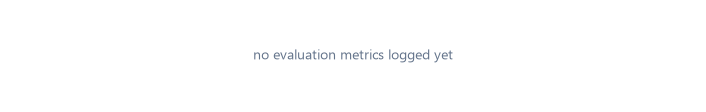

In [15]:
for _p in range(1, training_plots.metric_pages(TASK, exp=EXP) + 1):
    FIGS.save(training_plots.all_eval_metrics(TASK, _p, exp=EXP), f"eval_metrics_p{_p}",
        caption="Each logged development metric against training step, one panel per metric and one figure per metric group, credit-prior and control means over the finished arms; the title marks the improving direction or target value, drawn as a dashed line.");

## D · Every arm on its own

For the reader who wants to check one configuration rather than trust a mean.

### D1 · Every configuration, seed by seed

**What it shows.** One panel per configuration in the sweep map's order: its seeds as separate lines of the development score, all panels on shared axes; a line that stops early belongs to an unfinished arm.

**Why it matters.** An arm that behaved unlike its neighbours, or unlike its own other seeds, stands out here and disappears in every mean.

**What it says.** No arm has run yet; the figure below is a placeholder.

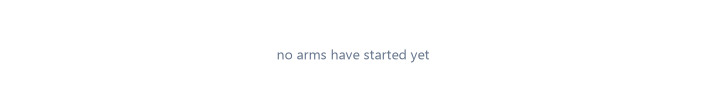

In [16]:
for _p in range(1, training_plots.config_pages(TASK, exp=EXP) + 1):
    FIGS.save(training_plots.per_config(TASK, _p, exp=EXP), f"per_config_p{_p}",
        caption="Development ROC-AUC against training step, one panel per configuration in sweep-map order with one line per seed, all panels on shared axes; lines that stop early belong to unfinished arms.");

### D2 · The best arm and the worst

**What it shows.** The finished arms with the highest and the lowest final development score: training loss and development score side by side.

**Why it matters.** Did the worst arm fail to learn, or learn something that does not transfer? The loss answers the first question, the score the second.

**What it says.** No arm has run yet; the figure below is a placeholder.

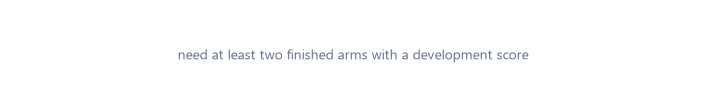

In [17]:
FIGS.save(training_plots.best_and_worst(TASK, exp=EXP), "best_and_worst",
    caption="Training loss (a rolling mean over three logged batches) and development ROC-AUC against training step for the best and the worst finished arm by final development score.");

## Summary

The sweep in text: the run (A), what the development monitoring says (B) and where it holds (C). Printed last, in the order of the sections above, so `output/All_Results.md` carries the
same story as this notebook, followed by the `tfm-library` sources it cites (pin `e5ce016`) and the
list of figures.

In [18]:
print(training_plots.training_summary(TASK, exp=EXP))
print()
print(literature.references_md(["batch", "stage1_lr", "optimizer", "filter_rate_clf", "filter_pval", "filter_extratrees_n", "merton_vasicek", "basel_corp"]))
print()
print(FIGS.summary())

EXP2 PD TRAINING — development-split monitoring
  no progress logs in output/manifests/ yet.

References (tfm-library pin e5ce016):
  - papers/2026/02_Qu_TabICLv2 §4.1  [paper-evaluated]
  - papers/2026/02_Qu_TabICLv2 §Data filtering, Fig. 10  [paper-evaluated]
  - TabICL.txt should_filter  [code-supported]
  - NanoTabICL.txt rand_dataset_filtered  [code-supported]
  - EXTERNAL — not in tfm-library (Merton 1974; Vasicek 2002)  [external]
  - EXTERNAL — Basel Committee IRB formula  [external]

2.1_pd_finetuning: 16 figures -> C:\Users\U0152019\PhD Documents\Projects\4. CreditICL\CreditICL\output\figures\2.1_pd_finetuning
  01  sweep_map
  02  monitoring_coverage
  03  throughput
  04  training_loss
  05  gradient_health
  06  metric_over_training
  07  credit_vs_control_over_training
  08  metric_by_levers
  09  final_metric_by_lever
  10  lever_interaction
  11  seed_spread
  12  per_dataset_p1
  13  real_vs_ood
  14  eval_metrics_p1
  15  per_config_p1
  16  best_and_worst
